# 1. 基础语法入门

## 1.1. 基础图构建

使用TypeDict作为状态管理

In [2]:
from tkinter import Image
from typing import TypedDict,Annotated
from operator import add
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel


# 1. 定义状态
class OverallState(TypedDict):
    # 日志类型是 list[str] ，更新方式不是覆盖 add 是追加
    logs:Annotated[list[str],add]
    cur_id:str

# 2. 定义节点
def node_1(state: OverallState) -> OverallState:
    pre_id = state['cur_id']
    return {
        'logs':['node_1 运行完毕'],
        'cur_id':pre_id + ', node_1'
    }

# 2. 定义节点
def node_2(state: OverallState) -> OverallState:
    pre_id = state['cur_id']
    return {
        'logs':['node_2 运行完毕'],
        'cur_id':pre_id + ', node_2'
    }

# 3. 定义边
# 3.1 初始化图
builder = StateGraph(state_schema=OverallState)
builder.add_node(node_1)
builder.add_node(node_2)

# 3.2. 添加边
builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2",END)

# 4. 编译图
graph = builder.compile()

# 5. 运行
result = graph.invoke({"cur_id":"start"})
print(result)


{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


打印流程图 / 图片

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



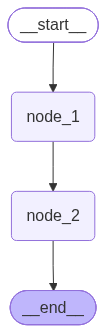

In [5]:
from IPython.display import display,Image


raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

png_bytes = graph.get_graph().draw_mermaid_png()
png = Image(png_bytes)
display(png)


使用Pydantic.BaseModel作为状态管理

In [6]:
from tkinter import Image
from typing import TypedDict,Annotated
from operator import add
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel


# 1. 定义状态
class OverallState(BaseModel):
    # 日志类型是 list[str] ，更新方式不是覆盖 add 是追加
    logs:Annotated[list[str],add]
    cur_id:str

# 2. 定义节点
def node_1(state: OverallState) -> OverallState:
    pre_id = state.cur_id
    return {
        'logs':['node_1 运行完毕'],
        'cur_id':pre_id + ', node_1'
    }

# 2. 定义节点
def node_2(state: OverallState) -> OverallState:
    pre_id = state.cur_id
    return {
        'logs':['node_2 运行完毕'],
        'cur_id':pre_id + ', node_2'
    }

# 3. 定义边
# 3.1 初始化图
builder = StateGraph(state_schema=OverallState)
builder.add_node(node_1)
builder.add_node(node_2)

# 3.2. 添加边
builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2",END)

# 4. 编译图
graph = builder.compile()

# 5. 运行
result = graph.invoke({"cur_id":"start"})
print(result)


{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


学习LangChain的结构化输出时我们提到：Pydantic对格式要求最严格，如果模型返回的内容不符合结构化Schema的要求，则抛出ValidationError。而其余方式都不会对模型的返回结果进行校验，即便模型返回的内容不符合结构化要求，也会原样返回给用户。

而作为LangGraph计算图的状态时，这三种方式都要求字段名称完全一致。只是处理方式不同。具体规则如下

3.1.4.1. 输入字段不匹配
1. TypedDict
TypedDict将输入字段视为字典的Key，不匹配时抛出KeyError异常。

2. dataclass
dataclass将输入字段视为类的属性，不匹配时抛出TypeError（类型错误）异常。

3. Pydantic
Pydantic对输入字段进行校验，不匹配时抛出ValidationError异常。

3.1.4.2. 节点返回字段不匹配
图节点返回的是对于状态的更新，如果返回字段和状态字段不匹配，上述三种Schema定义方式的行为是统一的：状态更新会被忽略。

3.1.5. 推荐用法
在实际使用中，推荐优先使用 TypedDict 定义 LangGraph 状态图的 State Schema。

大多数官方案例也采用 TypedDict 方式定义状态 Schema。这种方式写法简洁、结构清晰，能够直接描述状态中包含哪些字段，以及每个字段对应的数据类型，非常适合用于定义图运行过程中的共享状态。

相比普通 dict，TypedDict 可以提供更明确的字段约束和类型提示；相比 dataclass，TypedDict 更贴近 LangGraph 中状态的更新方式，因为节点通常返回的是表示“部分状态更新”的字典，而不是完整对象；相比 Pydantic BaseModel，它又更加轻量，不会引入额外的数据校验开销。因此，在没有复杂校验需求的情况下，TypedDict 是定义 LangGraph State Schema 的首选方式。



## 1.2. Reducer



In [8]:
def my_reducer(left: list[str],right: list[str]) -> list[str]:
    return left + right

left = ['start','node_1']
right = ['node_2']
result = my_reducer(left,right)
print(result)

['start', 'node_1', 'node_2']
